In [5]:
import pandas as pd

data = pd.read_csv('data/dataset.csv')

data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\r\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\r\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\r\nCobbborough,...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\r\nPort Jason, OH 22070-...",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\r\nPort Jacobville, PR...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [6]:
print("Shape:")
print(data.shape)

print("\nInfo:")
data.info()

print("\nDescription:")
print(data.describe())

Shape:
(500, 8)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 69.8 KB

Description:
       Avg. Session Length  Time on App  Time on Website  \
count           500.000000   500.000000       500.000000   
mean             33.053194    12.052488        37.060445   
std               0.992563     0.994216         1.010489   
min              29.532429     8.508152        33.913847   
25%        

In [4]:
import os

print(os.listdir('data'))

['dataset.csv', 'Titanic-Dataset-selected.csv']


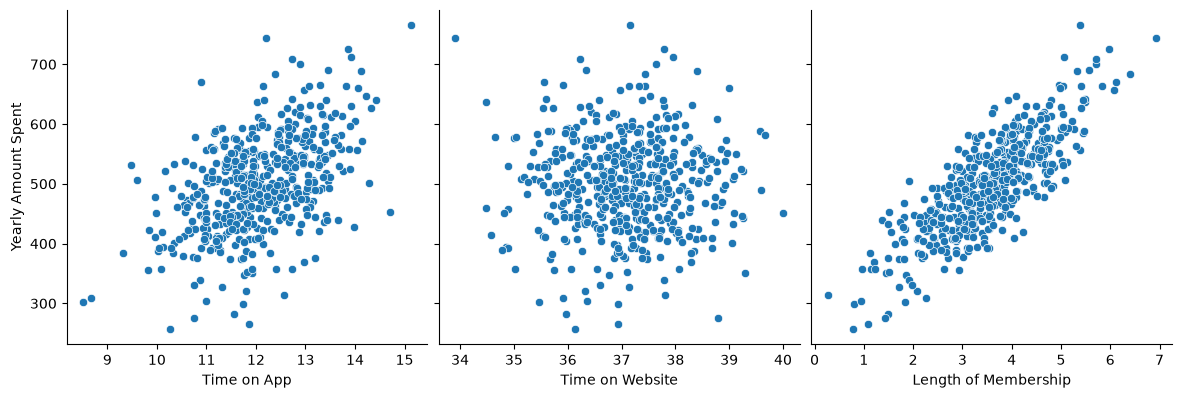

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(
    data,
    x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
    y_vars='Yearly Amount Spent',
    height=4,
    aspect=1,
    kind='scatter'
)

plt.show()

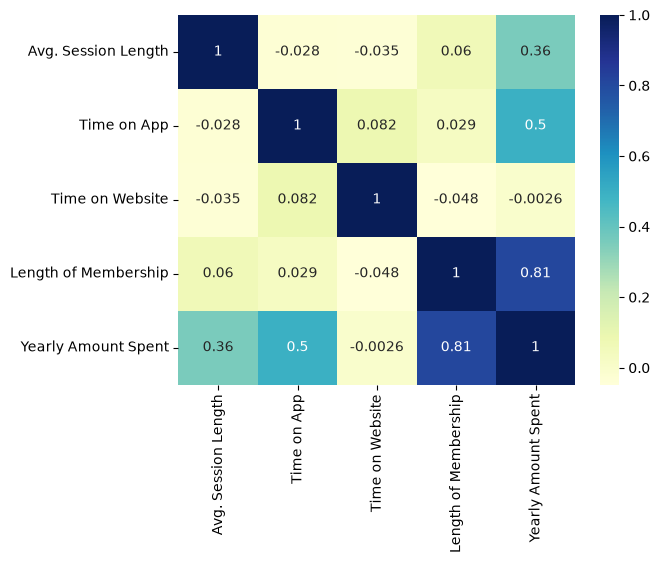

In [8]:
sns.heatmap(
    data.corr(numeric_only=True),
    cmap="YlGnBu",
    annot=True
)

plt.show()

In [9]:
X = data['Length of Membership']
y = data['Yearly Amount Spent']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    test_size=0.3,
    random_state=100
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (350,)
Testing data: (150,)


In [11]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

lr = sm.OLS(y_train, X_train_sm).fit()

print(lr.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.669
Model:                             OLS   Adj. R-squared:                  0.668
Method:                  Least Squares   F-statistic:                     702.9
Date:                 Wed, 30 Sep 2026   Prob (F-statistic):           1.59e-85
Time:                         11:05:07   Log-Likelihood:                -1841.3
No. Observations:                  350   AIC:                             3687.
Df Residuals:                      348   BIC:                             3694.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

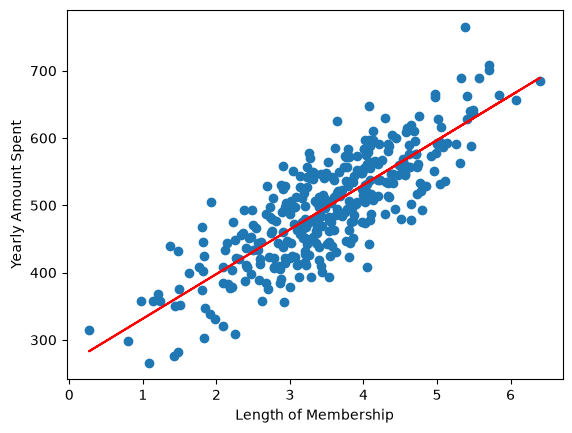

In [12]:
plt.scatter(X_train, y_train)

plt.plot(
    X_train,
    265.2483 + 66.3015 * X_train,
    'r'
)

plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')
plt.show()

In [13]:
y_train_pred = lr.predict(X_train_sm)

# Hitung residual
res = y_train - y_train_pred

print(res.head())

153   -11.119759
84    -23.238076
310    -8.632781
494    61.834396
126   -20.654448
dtype: float64


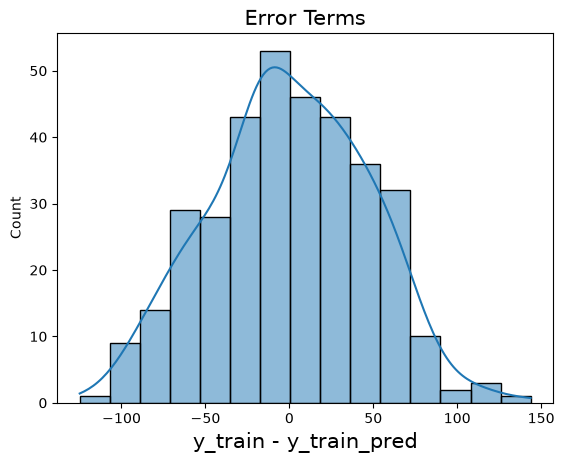

In [14]:
fig = plt.figure()

sns.histplot(res, bins=15, kde=True)

plt.title('Error Terms', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=15)

plt.show()

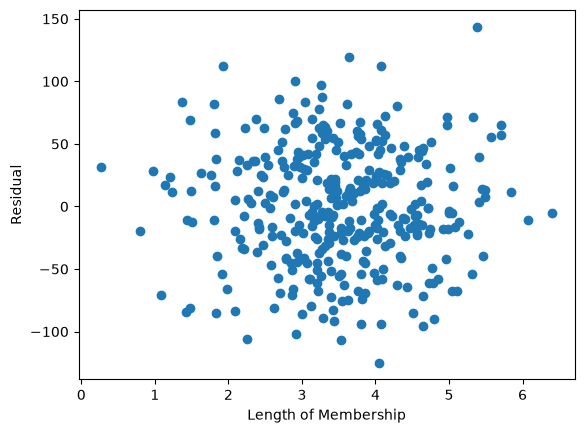

In [15]:
plt.scatter(X_train, res)

plt.xlabel('Length of Membership')
plt.ylabel('Residual')

plt.show()

In [16]:
X_test_sm = sm.add_constant(X_test)

y_test_pred = lr.predict(X_test_sm)

In [17]:
from sklearn.metrics import r2_score

r_squared = r2_score(y_test, y_test_pred)

print("R-squared:", r_squared)

R-squared: 0.6119489137687472


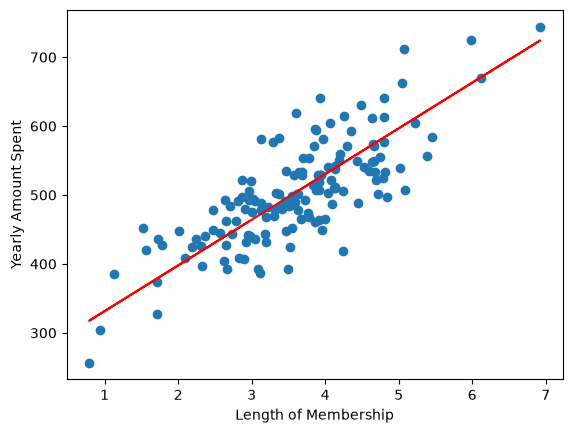

In [18]:
plt.scatter(X_test, y_test)

plt.plot(X_test, y_test_pred, 'r')

plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')

plt.show()